In [62]:
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D
import matplotlib.ticker as plticker
import matplotlib.pyplot as plt
from matplotlib.pyplot import MultipleLocator
import matplotlib.ticker as mtick
import matplotlib as mpl
import seaborn as sns
import umap
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from sklearn.preprocessing import StandardScaler
from descriptastorus.descriptors import rdDescriptors, rdNormalizedDescriptors
#clustering
import argparse,time
from rdkit.Chem import AllChem as Chem
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem.Draw import IPythonConsole
from rdkit.ML.Cluster import Butina
from rdkit.Chem import Draw
from rdkit.Chem import rdFingerprintGenerator
import os

mpl.rcParams['mathtext.default'] = 'regular'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams["figure.dpi"] = 300
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

In [ ]:
#UMAP
def read_mols(path):
    with open(path, 'r') as f:
        smis = [l.rstrip() for l in f]
    mols = []
    smis_failed = []
    for smi in smis:
        mol = Chem.MolFromSmiles(smi)
        if mol:
            mols.append(mol)     
        else:
            smis_failed.append(smi)       
    print(smis_failed)
    return mols

def get_fps(mols):
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=3,fpSize=2048,
                atomInvariantsGenerator=rdFingerprintGenerator.GetMorganFeatureAtomInvGen()) #FCFP_6
    # generator = rdFingerprintGenerator.GetMorganGenerator(radius=3,fpSize=2048)
    # generator = rdNormalizedDescriptors.RDKit2DNormalized()
    # generator = rdDescriptors.RDKit2D()
    fps = []
    for mol in mols:
        fp = generator.GetFingerprintAsNumPy(mol)
        # smi = Chem.MolToSmiles(mol)
        # fp = generator.process(smi)[1:]
        fps.append(fp)
    return np.array(fps)

def embedding_umap(data):
    data_scaled = StandardScaler().fit_transform(data)
    reducer = umap.UMAP(n_neighbors=40,
                        min_dist=0.8,
                        metric='correlation',
                        random_state=42)
    embeds = reducer.fit_transform(data_scaled)
    # embeds = reducer.fit_transform(data)
    return embeds

In [43]:
sampled_mols = read_mols('sampled_preped.smi')
known_ligands = read_mols('rock_ligands.smi')
mols_f5 = [Chem.MolFromSmiles('O=C(N1CCC(C(N2CC=C(C3=CC=CC=C3)CC2)=O)CC1)C4=NNC(C5=NC=CC=C5)=C4')]
mols_8413 = [Chem.MolFromSmiles('O=C(NC1=CC(C2=NC3=CC=C(C#N)C=C3N2)=CC=C1)NC4=CC=CC(C5=CNN=C5)=C4')]

[19:10:12] Explicit valence for atom # 14 Br, 3, is greater than permitted
[19:10:12] Explicit valence for atom # 19 Cl, 3, is greater than permitted
[19:10:13] Explicit valence for atom # 1 Cl, 5, is greater than permitted
[19:10:13] Explicit valence for atom # 12 Br, 3, is greater than permitted
[19:10:13] Explicit valence for atom # 22 Cl, 3, is greater than permitted
[19:10:14] Explicit valence for atom # 16 Cl, 3, is greater than permitted
[19:10:14] Explicit valence for atom # 1 Br, 3, is greater than permitted
[19:10:14] Explicit valence for atom # 12 Cl, 3, is greater than permitted
[19:10:14] Explicit valence for atom # 18 Br, 3, is greater than permitted
[19:10:14] Explicit valence for atom # 20 Cl, 3, is greater than permitted
[19:10:14] Explicit valence for atom # 11 Cl, 3, is greater than permitted
[19:10:15] Explicit valence for atom # 5 Cl, 3, is greater than permitted
[19:10:15] Explicit valence for atom # 18 Cl, 3, is greater than permitted
[19:10:15] Explicit valence 

In [84]:
# sampled_mols_clustered = [Chem.MolFromSmiles(smi) for smi in center_df['smiles']]
sampled_fps = get_fps(sampled_mols)
g_f_fps = get_fps(known_ligands)
fps_f5 = get_fps(mols_f5)
fps_8413 = get_fps(mols_8413)
fps_all = np.concatenate((sampled_fps, g_f_fps, fps_f5, fps_8413), axis=0)
fps_all_32 = np.float32(fps_all)

In [89]:
fps_all_32.shape

(26608, 2048)

In [86]:
len(sampled_fps)

25974

In [90]:
fps_embeds = embedding_umap(fps_all_32)

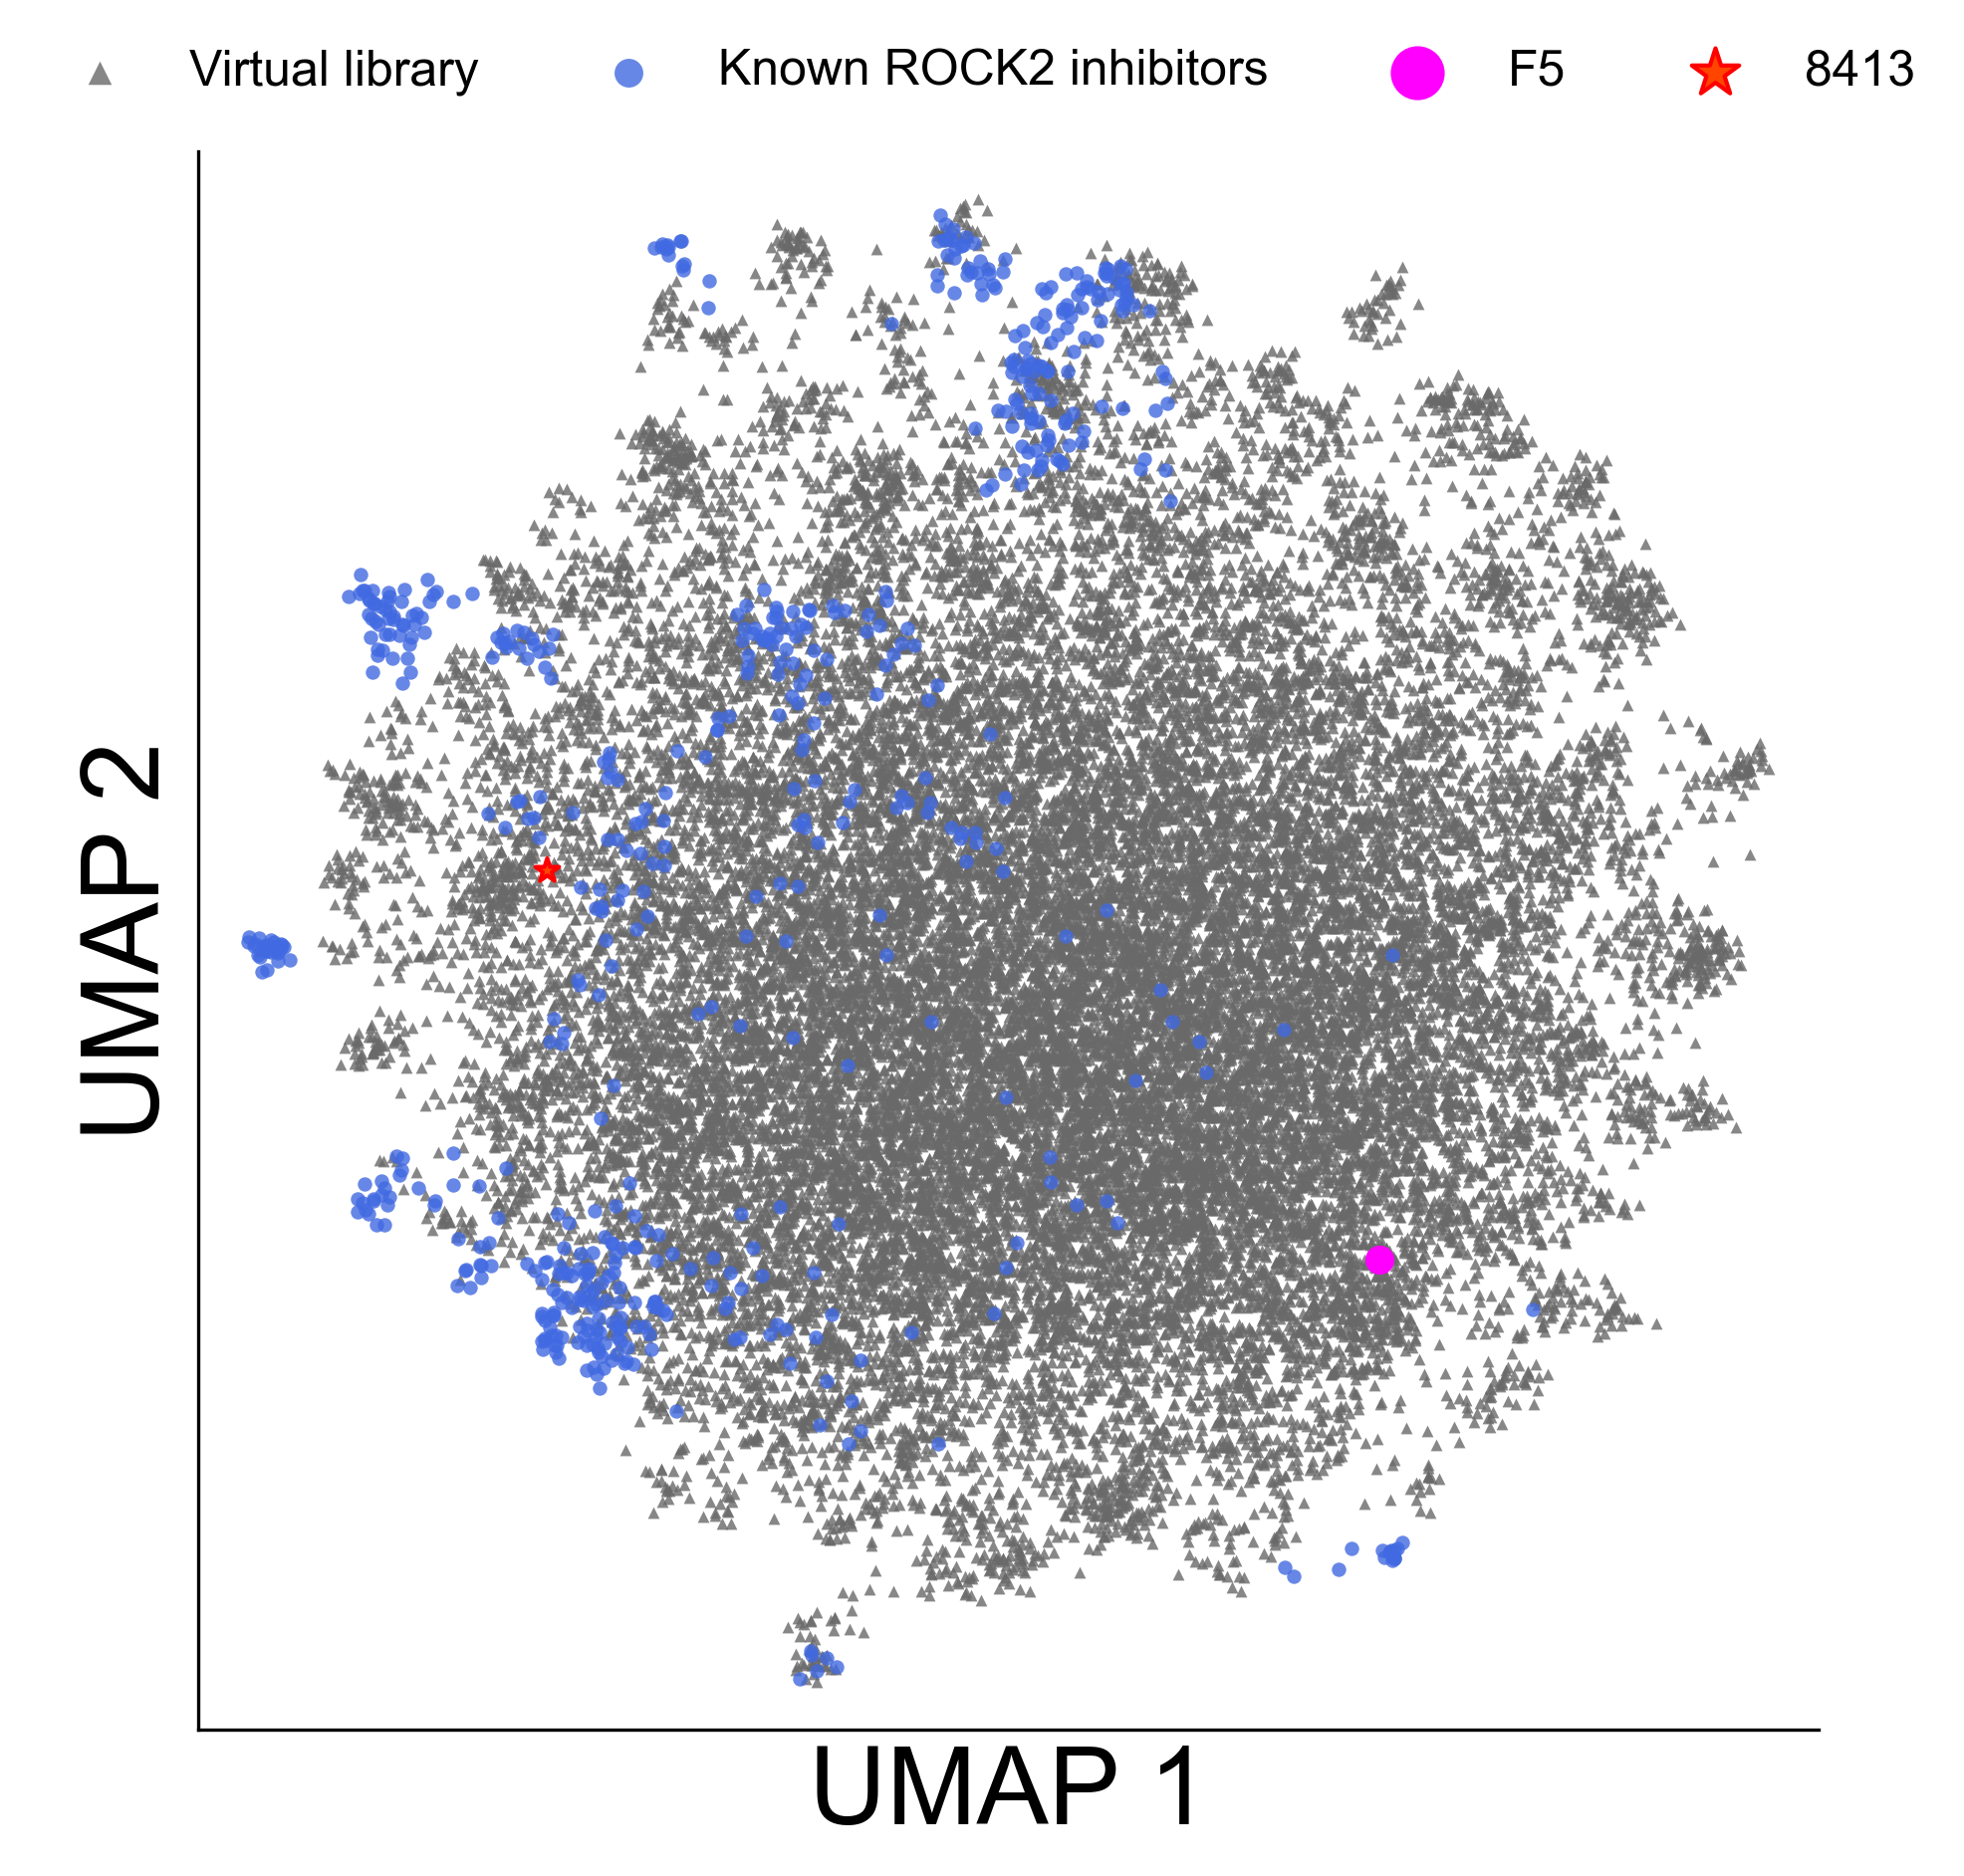

In [94]:
fig, ax = plt.subplots(1,1, figsize=(7, 7))
legend_elements = [Line2D([0], [0], marker='o', color='r', markeredgecolor="dimgrey",
                          markerfacecolor='grey', markersize=2.5),
                Line2D([0], [0], marker='^', color='r', 
                          markerfacecolor='royalblue', markersize=2.5),
                Line2D([0], [0], marker='*', color='r',
                          markerfacecolor='indianred', markersize=2.5),
                Line2D([0], [0], marker='*', color='r',
                          markerfacecolor='red', markersize=2.5),]
labels = ['Virtual library', 'Known ROCK2 inhibitors', 'F5', '8413']   

s_sampled = ax.scatter(fps_embeds[:len(sampled_fps), 0], fps_embeds[:len(sampled_fps), 1],
        c="dimgrey", s=8, marker="^", edgecolors="grey", linewidths=0,alpha=0.8)
s_f = ax.scatter(fps_embeds[len(sampled_fps):(len(sampled_fps)+len(g_f_fps)), 0], fps_embeds[len(sampled_fps):(len(sampled_fps)+len(g_f_fps)), 1],
        c="royalblue", s=12,edgecolors="blue", linewidths=0,alpha=0.8)
s_f5 = ax.scatter(fps_embeds[-2:-1, 0], fps_embeds[-2:-1, 1],
        c="magenta", s=36,edgecolors="magenta", linewidths=1,alpha=1,marker="o")
s_8413 = ax.scatter(fps_embeds[-1:, 0], fps_embeds[-1:, 1],
        c="orangered", s=36,edgecolors="red", linewidths=1,alpha=1,marker="*")

ax.set_xlim([np.min(fps_embeds[:,0])-0.5, np.max(fps_embeds[:,0])+0.5])
ax.set_ylim([np.min(fps_embeds[:,1])-0.5, np.max(fps_embeds[:,1])+0.5])
plt.setp(ax.get_xticklabels(), visible=False)
plt.setp(ax.get_yticklabels(), visible=False)
ax.tick_params(axis='both', which='both',length=0)
ax.set_xlabel('UMAP 1',size=26)
ax.set_ylabel("UMAP 2",size=26)
fig.legend((s_sampled, s_f, s_f5, s_8413), labels)
sns.move_legend(fig, "upper center",bbox_to_anchor=(.5, 0.95), ncol=4, 
                title=None, frameon=False, prop={"size":12}, markerscale=2)
ax.spines[['right', 'top']].set_visible(False)
# fig.savefig("FigS4.pdf", transparent=True, bbox_inches='tight')
fig.savefig("Fig-UMAP.png", bbox_inches='tight')